In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['figure.figsize'] = 12,6
plt.rcParams['font.size'] = 14
plt.rcParams['axes.unicode_minus'] = False

# 데이터 전처리 관련 ####################################################
# 결측치 처리
from sklearn.impute import SimpleImputer
# 표준화
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
# 인코더
from sklearn.preprocessing import LabelEncoder
# 원핫 인코더
from sklearn.preprocessing import OneHotEncoder

# 학습 모델 성능 관련 ####################################################
# 원하는 비율로 데이터를 나누기 위해
from sklearn.model_selection import train_test_split
# K-Fold 교차 검증
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold
# 학습곡선
from sklearn.model_selection import learning_curve
# 하이퍼 파라미터 튜닝
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
import optuna
from optuna.samplers import TPESampler # 데이터를 랜덤샘플링하기 위함
from optuna.pruners import MedianPruner
optuna.logging.set_verbosity(optuna.logging.WARNING) # 수치가 떨어지면 경고로그가 뜨는데 그거를 막아줌

# 모델 성능평가 #############################################
# 회귀용
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import r2_score
# 분류용
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

from sklearn.metrics import roc_curve
from sklearn.metrics import auc
from sklearn.metrics import roc_auc_score
from sklearn.metrics import ConfusionMatrixDisplay

# 피처 선택 ################################################
from sklearn.feature_selection import VarianceThreshold
from sklearn.feature_selection import RFE
from sklearn.inspection import permutation_importance

# 학습모델 ##################################################
#분류
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.naive_bayes import GaussianNB
from catboost import CatBoostClassifier

#회귀
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNet
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import BayesianRidge
from catboost import CatBoostRegressor

# 결정트리를 시각화할 수 있는 라이브러리
from sklearn.tree import plot_tree

# 차원축소
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.manifold import TSNE

# 연관규칙 학습
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import fpgrowth
from mlxtend.frequent_patterns import association_rules

# 군집
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.mixture import GaussianMixture
from sklearn.cluster import MeanShift, estimate_bandwidth

# 파이프라인
from sklearn.pipeline import Pipeline

# KDE를 그리기 위한 통계값을 구할 수 있는 함수
from scipy.stats import gaussian_kde

# 피어슨 상관 계수 (연속형 수치형 데이터 vs 연속형 수치형 데이터)
from scipy.stats import pearsonr
# 카이제곱 검증 (범주형 데이터 vs 범주현 데이터, 순위 x)
from scipy.stats import chi2_contingency
# 스피어만 상관계수 (범주형 데이터 vs 범주형 데이터, 순위 O)
from scipy.stats import spearmanr
# 포인트 이분 상관계수 (범주형 데이터 vs 연속형 수치형 데이터)
from scipy.stats import pointbiserialr
# 독립 표본 T-검정 (독립관계를 같는 두 표본의 평균의 차이가 통계적으로 유의미한가)
from scipy.stats import ttest_ind

# 오버 샘플링
from imblearn.over_sampling import SMOTE

# 객체를 파일에 저장
import pickle

# 불필요한 경고 뜨지 않게
import warnings
warnings.filterwarnings('ignore')

### 데이터 가져오기

In [2]:
df = pd.read_csv('data/Mall_Customers.csv')
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [3]:
# 컬럼명 변경
df.columns = ['ID', 'Gender', 'Age', 'Income', 'Score']
df

,ID,Gender,Age,Income,Score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [4]:
# 기초 통계량 분석
# 데이터 명세서가 있다면 이상치를 확인
# 표준편차 확인
df.describe()


,ID,Age,Income,Score
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [5]:
# 결측치 확인
df.isna().sum()

ID        0
Gender    0
Age       0
Income    0
Score     0
dtype: int64

In [6]:
# 피어슨 상관계수를 구해 히트맵을 그려본다.
a1 = df[['Age','Income','Score']].corr()
a1

,Age,Income,Score
Age,1.000000,-0.012398,-0.327227
Income,-0.012398,1.000000,0.009903
Score,-0.327227,0.009903,1.000000


- Score랑 Age는 상관계수가 낮고
- Score랑 Income은 상관계수가 높음

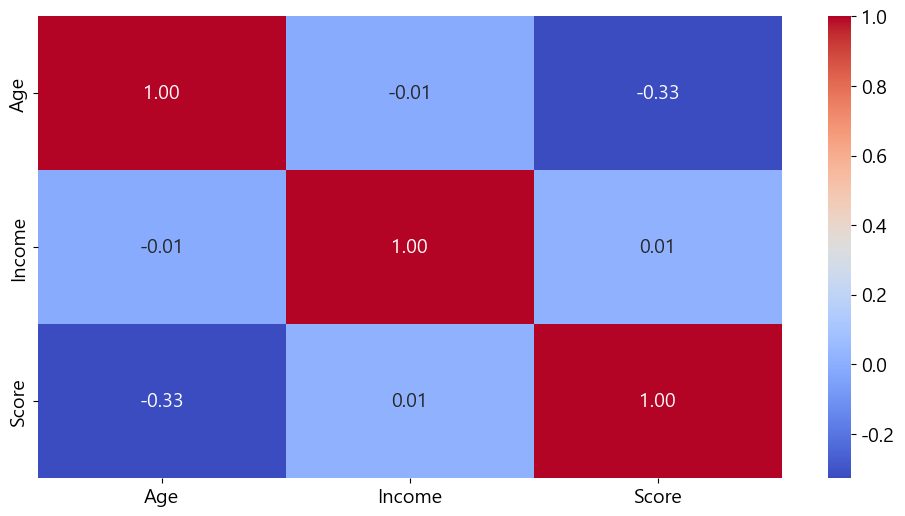

In [7]:
sns.heatmap(a1, annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

### 가설 1 : MZ세대 (35세 이하)의 "소득-소비 역전" 현상
- 소득 수준과 관계없이 나이가 어린 집단은 소비 점수가 월등히 높을 것이다.

In [8]:
# 35세를 기준으로 MZ 세대 여부 정의
df['Is_Young'] = 0

idx1 = df.query('Age <=35').index
df.loc[idx1, 'Is_Young'] = 1
df

,ID,Gender,Age,Income,Score,Is_Young
0,1,Male,19,15,39,1
1,2,Male,21,15,81,1
2,3,Female,20,16,6,1
3,4,Female,23,16,77,1
4,5,Female,31,17,40,1
...,...,...,...,...,...,...
195,196,Female,35,120,79,1
196,197,Female,45,126,28,0
197,198,Male,32,126,74,1
198,199,Male,32,137,18,1


In [9]:
# 1달러당 소비 점수 효율을 계산
df['Spending_Ratio'] = df['Score'] /df['Income']
df

,ID,Gender,Age,Income,Score,Is_Young,Spending_Ratio
0,1,Male,19,15,39,1,2.600000
1,2,Male,21,15,81,1,5.400000
2,3,Female,20,16,6,1,0.375000
3,4,Female,23,16,77,1,4.812500
4,5,Female,31,17,40,1,2.352941
...,...,...,...,...,...,...,...
195,196,Female,35,120,79,1,0.658333
196,197,Female,45,126,28,0,0.222222
197,198,Male,32,126,74,1,0.587302
198,199,Male,32,137,18,1,0.131387


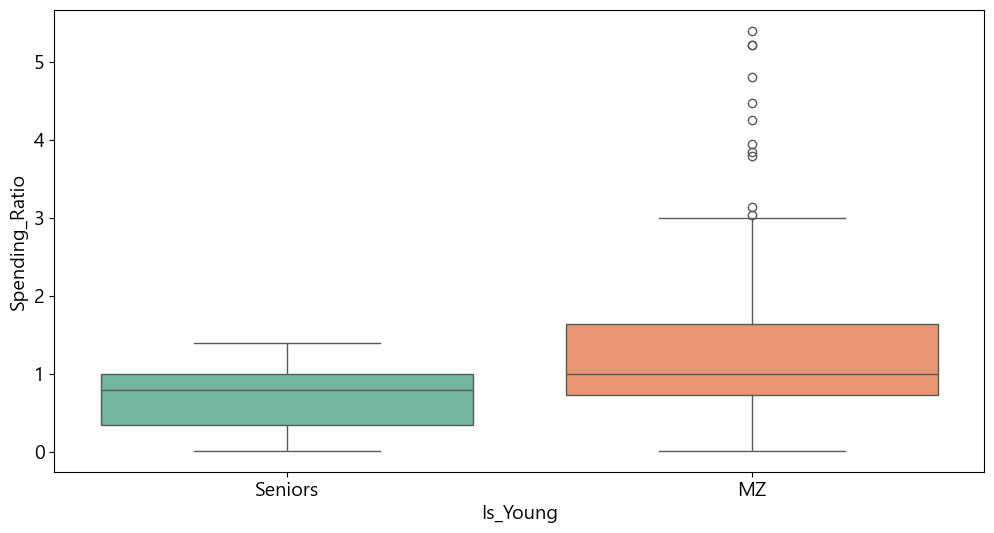

In [10]:
# MZ 세대와 기성세대의 소비 효율 분포 차이를 확인한다.
sns.boxplot(x='Is_Young', y='Spending_Ratio', data=df, palette='Set2')
plt.xticks([0,1], ['Seniors', 'MZ'])
plt.show()

In [11]:
# 독립표본 T-검정을 통해 두 집단의 평균 차이가 통계적으로 유의미한지 확인한다.
seniors_group = df.query('Is_Young == 0')
mz_group = df.query('Is_Young == 1')

_, p_value = ttest_ind(seniors_group['Spending_Ratio'], mz_group['Spending_Ratio'])

print(f'p_value : {p_value:.4f}')

p_value : 0.0000


- p_value가 0.05보다 작으므로 MZ 세대(35세 이하)와 그렇지 않은 세대들간의 소비율의 평균은 통계적으로 의미있는 차이를 보이지 않는다는 귀무가설을 기각한다.
- 두 집단간의 소비율의 평균의 차이를 보인다.

### 가설2 : 고소득 장년층의 "신중한 자산가" 패턴
- 나이와 소득이 모두 높은 집단은 자산은 많으나 지출에는 신중하여 소비 점수가 평균에 수렴할 것이다.

In [12]:
# 나이와 소득을 곱하여 '누적 자산 잠재력'을 대변하는 지표를 만든다.
df['Age_Income_Product'] = df['Age'] * df['Income']
df

,ID,Gender,Age,Income,Score,Is_Young,Spending_Ratio,Age_Income_Product
0,1,Male,19,15,39,1,2.600000,285
1,2,Male,21,15,81,1,5.400000,315
2,3,Female,20,16,6,1,0.375000,320
3,4,Female,23,16,77,1,4.812500,368
4,5,Female,31,17,40,1,2.352941,527
...,...,...,...,...,...,...,...,...
195,196,Female,35,120,79,1,0.658333,4200
196,197,Female,45,126,28,0,0.222222,5670
197,198,Male,32,126,74,1,0.587302,4032
198,199,Male,32,137,18,1,0.131387,4384


<Axes: xlabel='Age_Income_Product', ylabel='Score'>

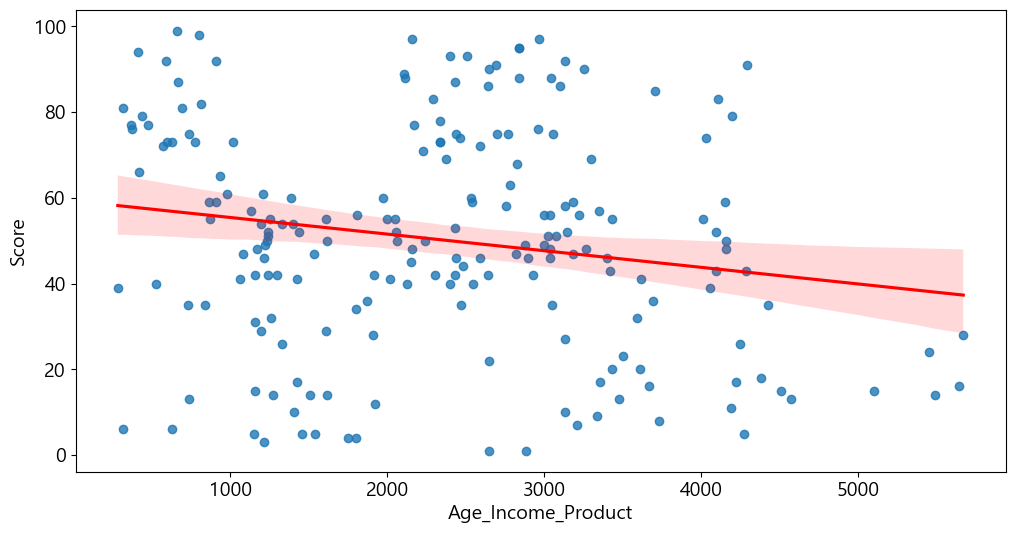

In [14]:
# 산점도와 회귀선을 통해 자산 지표가 높아질 수록 소비 점수가 어떻게 변하는지 확인한다.
sns.regplot(x='Age_Income_Product', y='Score', data=df, line_kws={'color' : 'red'})

In [17]:
# 피어슨 상관분석을 통해 두 변수간의 연관성 수치를 도출한다.
_, p_value = pearsonr(df['Age_Income_Product'],df['Score'])
print(f'p_value : {p_value:.4f}')

p_value : 0.0091


- p_value가 0.05이므로 자산이 변하더라도 소비 점수는 통계적으로 유의미한 변화를 보이지 않는다는 귀무가설을 기각한다.
- 이제 자산이 변함에 따라 소비점수가 변한다는 가설을 채택한다.
- 위의 그래프를 보면 자산이 높을수록 소비점수가 하락하는 것을 확인할 수 있다.

### 가설3 : 성별에 따른 소득 민감도 차이
- 남성과 여성은 소득 증가에 따라 소비점수가 올라가는 민감도(기울기)가 다를 것이다.

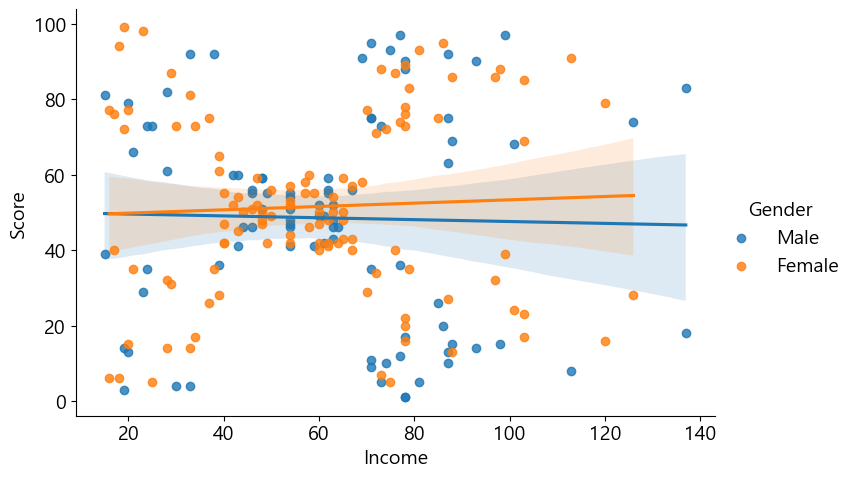

In [22]:
# lmplot : 두 집단간의 산점도와 회귀선을 표현해준다.
sns.lmplot(x='Income', y='Score', hue='Gender', data=df, aspect=1.5)
plt.show()

- 남성은 소득이 많을수록 소비지수가 약간 하락
- 여성은 소득이 많을수록 소비지수가 약간 상향

### 가설4 : 저소득 고효율 '얼리어댑터' 군집 존재 여부
- 소득은 적지만 소비율이 높은 그룹이 존재할 것이다.
- 특정 취향에 집중 투입하는 '가성비 매니아' 그룹이 존재할 것이다.

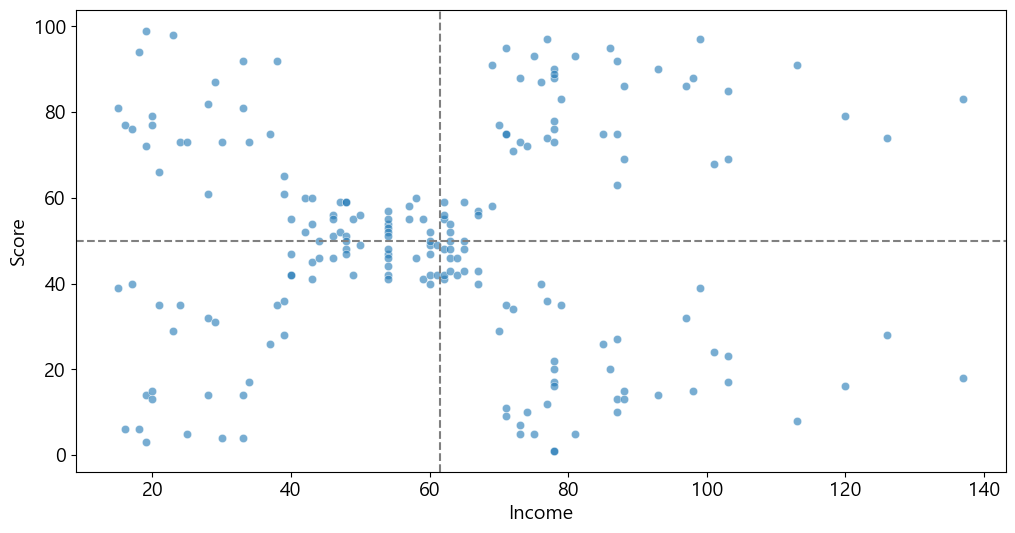

In [30]:
sns.scatterplot(x='Income', y='Score', data=df, alpha=0.6)
plt.axvline(df['Income'].median(), color='gray', linestyle='--')
plt.axhline(df['Score'].median(), color='gray', linestyle='--')
plt.show()

- 소득은 낮지만 소비가 낮은 그룹이 존재
- 소득은 낮지만 소비가 높은 그룹이 존재
- 소득은 높지만 소비가 낮은 그룹이 존재
- 소득은 높지만 소비가 높은 그룹이 존재
- 소득과 소비가 균형을 이루는 그룹이 존재

### EDA 및 가설 검증 결과 요약

- 데이터 품질 확인 : 결측치가 없으며, Income과 Score간에 시각적으로 뚜렷한 군집 경향이 관찰된다.
- 가설의 유효성 확인 : T-test 및 상관분석을 통해 생성된 파생 피쳐들이 실제 집단 간 차이를 만드는 핵심 변수임을 확인했다.
- 모델링 전략 수립 : 단순한 기본 컬럼 분석을 넘어, 우리가 입증한 가설 기반의 다차워 피처들을 모두 사용하여 K-Means 모델의 변수로 투입할 근거를 마련했다.

In [31]:
df.to_csv('data/Mall_Customers2.csv',index=False)